# 055. 양방향 LSTM을 이용한 개체명 인식(Named Entity Recognition using Bi-LSTM)

- 개체명 인식은 챗봇 등에서 필요로 하는 주요 전처리 작업  (질문 문장의 어절을 일반화시키는 과정에서 개체명(Named Entity) 인식 사전을 활용)


- 도메인 또는 목적에 특화되도록 개체명 인식을 정확하게 하는 방법 중 하나는 기존에 공개된 개체명 인식기를 사용하는 것이 아니라, 직접 목적에 맞는 데이터를 준비하여 기계를 훈련시켜 모델을 만드는 방법임  


### BIO 
- B (Begin) - 개체명이 시작되는 부분  
- I (Inside) - 개체명의 내부 부분  
- O (Outside) - 개체명이 아닌 부분


- 각 개체가 어떤 종류인지도 함께 태깅  
```
해 B-movie  
리 I-movie  
포 I-movie  
터 I-movie  
보 O  
러 O  
메 B-theater  
가 I-theater  
박 I-theater  
스 I-theater  
가 O  
자 O  
```



### CoNLL2003 dataset 이용

- CoNLL -  the Conference on Natural Language Learning  


- https://raw.githubusercontent.com/Franck-Dernoncourt/NeuroNER/master/neuroner/data/conll2003/en/train.txt  에서 download  



- [word][pos Tagging][chunk tagging][named entity tagging] 의 4 column 형식으로 구성   


- NE taggin : LOC - location, ORG - organization, PER - person, MISC - miscellaneous, B - phrase 시작, I - inside phrase, O - phrase 의 일부가 아님
```
The DT B-NP O                             # 개체명 아님               
European NNP I-NP B-ORG            # ORG type phrase 시작 
Commission NNP I-NP I-ORG         # phrase 에 속함 - ORG
said VBD B-VP O                           # 개체명 아님
on IN B-PP O
Thursday NNP B-NP O
it PRP B-NP O
disagreed VBD B-VP O
with IN B-PP O
German JJ B-NP B-MISC                # MISC type phrase 시작
advice NN I-NP O
to TO B-PP O
consumers NNS B-NP O
to TO B-VP O
shun VB I-VP O
```

## Dataset download 및 전처리

In [0]:
import re
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Embedding, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import numpy as np

- `-DOCSTART- -X- -X- O` 로 file 시작
-  문장 사이는 empty line 으로 구분 

In [2]:
file_path = tf.keras.utils.get_file("train.txt", 
            "https://raw.githubusercontent.com/Franck-Dernoncourt/NeuroNER/master/neuroner/data/conll2003/en/train.txt")

3284992/3283420 [==============================] - 0s 0us/step


In [0]:
tagged_sentences = []
sentence = []

for line in open(file_path, 'r'):
    if len(line) == 0 or line.startswith('-DOCSTART') or line[0] == "\n":
        if len(sentence) > 0:
            tagged_sentences.append(sentence)
            sentence = []
        continue
        
    word, pos_tag, chunk_tag, ner = line.split(' ')  # 공백을 기준으로 속성을 구분 
    ner = re.sub('\n', '', ner)                                #['German', 'JJ', 'B-NP', 'B-MISC\n']
    word = word.lower()                                      # 단어들은 소문자로 바꿔서 저장
    sentence.append((word, ner))                        # 단어와 개체명 태깅만 사용

In [5]:
print("전체 샘플 개수: ", len(tagged_sentences)) # 전체 샘플의 개수 출력
tagged_sentences[:3]

전체 샘플 개수:  14041


[[('eu', 'B-ORG'),
  ('rejects', 'O'),
  ('german', 'B-MISC'),
  ('call', 'O'),
  ('to', 'O'),
  ('boycott', 'O'),
  ('british', 'B-MISC'),
  ('lamb', 'O'),
  ('.', 'O')],
 [('peter', 'B-PER'), ('blackburn', 'I-PER')],
 [('brussels', 'B-LOC'), ('1996-08-22', 'O')]]

## Data 생성 이후는 POS-Tagger 와 동일한 algorithm 사용 

### input, label data 작성을 위해 단어와 tag 를 분리

In [6]:
sentences, sentence_tags =[], [] 

for tagged_sentence in tagged_sentences:
    sentence, tags = zip(*tagged_sentence)
    sentences.append(list(sentence))
    sentence_tags.append(list(tags))

# Let's see how a sequence looks
print(sentences[0])
print(sentence_tags[0])

['eu', 'rejects', 'german', 'call', 'to', 'boycott', 'british', 'lamb', '.']
['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


샘플의 최대 길이 : 113
샘플의 평균 길이 : 14.501887


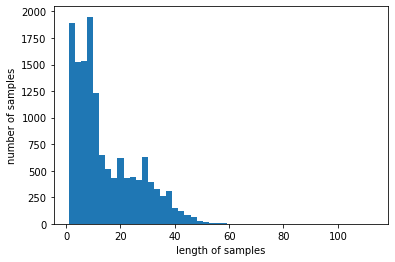

In [7]:
print('샘플의 최대 길이 : {}'.format(max([len(w) for w in sentences])))
print('샘플의 평균 길이 : {:4f}'.format(np.mean([len(w) for w in sentences])))
plt.hist([len(s) for s in sentences], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

**sample 들의 길이가 대체적으로 0-40의 길이를 가지며, 특히 0-20의 길이를 가진 샘플이 상당한 비율을 차지**

**keras 는 fixed size sequence 만 handling 가능하므로 max sequence length 를 60 으로 정함**

In [0]:
MAX_LENGTH = 60

### 전체 word 수 check

In [9]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

print(len(tokenizer.word_index))

21009


**전체 token 갯수가 21009 개 이므로 상위 4000 개로 제한하여 vocabulary 재작성**

- 문장 데이터에 대해서는 entity_tokenizer를, 레이블에 해당되는 개체명 태깅 정보에 대해서는 tag_tokenizer를 사용

In [0]:
MAX_WORDS = 4000

### train, test split

In [0]:
train_sentences, test_sentences, train_tags, test_tags \
                = train_test_split(sentences, sentence_tags, test_size=0.2)

### word vocabulary 작성

- train data 는 validation set 을 볼 수 없으므로, train_sentences 에 대해 tokenize 하고, label 은 전체 sentence_tags 에 대해 tokenize

In [12]:
input_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
input_tokenizer.fit_on_texts(train_sentences)

tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(sentence_tags)

vocab_size = input_tokenizer.num_words + 1
tag_size = len(tag_tokenizer.word_index) + 1

print('단어 집합의 크기 : {}'.format(vocab_size))
print('개체명 태깅 정보 집합의 크기 : {}'.format(tag_size))

단어 집합의 크기 : 4001
개체명 태깅 정보 집합의 크기 : 10


In [13]:
print(tag_tokenizer.word_index)

{'o': 1, 'b-loc': 2, 'b-per': 3, 'b-org': 4, 'i-per': 5, 'i-org': 6, 'b-misc': 7, 'i-loc': 8, 'i-misc': 9}


### pad sequences  

- sentence 와 tag 를 sequence 로 변환  

In [0]:
X_train = input_tokenizer.texts_to_sequences(train_sentences)
y_train = tag_tokenizer.texts_to_sequences(train_tags)

X_test = input_tokenizer.texts_to_sequences(test_sentences)
y_test = tag_tokenizer.texts_to_sequences(test_tags)

In [15]:
train_sentences_X = pad_sequences(X_train, maxlen=MAX_LENGTH, padding='post')
test_sentences_X = pad_sequences(X_test, maxlen=MAX_LENGTH, padding='post')
train_tags_y = pad_sequences(y_train, maxlen=MAX_LENGTH, padding='post')
test_tags_y = pad_sequences(y_test, maxlen=MAX_LENGTH, padding='post')
 
print(train_sentences_X[0])
print(test_sentences_X[0])
print(train_tags_y[0])
print(test_tags_y[0])

[1346    1    5    1  541  121   14    2  133  650   60   43    1 3287
   63    1  419    4    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]
[ 189   15 1324  247    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]
[3 5 1 4 6 6 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### n-to-n model 이므로 return_sequences=True 로 설정

In [16]:
model = Sequential()
model.add(Embedding(MAX_WORDS, 128))
model.add(Bidirectional(LSTM(256, return_sequences=True)))
model.add(Dense(tag_size))
model.add(Activation('softmax'))
 
model.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
 
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 128)         512000    
_________________________________________________________________
bidirectional (Bidirectional (None, None, 512)         788480    
_________________________________________________________________
dense (Dense)                (None, None, 10)          5130      
_________________________________________________________________
activation (Activation)      (None, None, 10)          0         
Total params: 1,305,610
Trainable params: 1,305,610
Non-trainable params: 0
_________________________________________________________________


In [0]:
cat_train_tags_y = to_categorical(train_tags_y, tag_size)
cat_test_tags_y = to_categorical(test_tags_y, tag_size)

In [26]:
%%time
model.fit(train_sentences_X, cat_train_tags_y , batch_size=128, epochs=10, 
              validation_data=(test_sentences_X, cat_test_tags_y))

Epoch 1/10
88/88 [==============================] - 91s 1s/step - loss: 0.1744 - accuracy: 0.9592 - val_loss: 0.1415 - val_accuracy: 0.9598
Epoch 2/10
88/88 [==============================] - 89s 1s/step - loss: 0.1158 - accuracy: 0.9655 - val_loss: 0.1026 - val_accuracy: 0.9693
Epoch 3/10
88/88 [==============================] - 90s 1s/step - loss: 0.0898 - accuracy: 0.9731 - val_loss: 0.0841 - val_accuracy: 0.9747
Epoch 4/10
88/88 [==============================] - 89s 1s/step - loss: 0.0700 - accuracy: 0.9793 - val_loss: 0.0671 - val_accuracy: 0.9810
Epoch 5/10
88/88 [==============================] - 91s 1s/step - loss: 0.0532 - accuracy: 0.9845 - val_loss: 0.0565 - val_accuracy: 0.9843
Epoch 6/10
88/88 [==============================] - 89s 1s/step - loss: 0.0420 - accuracy: 0.9877 - val_loss: 0.0498 - val_accuracy: 0.9863
Epoch 7/10
88/88 [==============================] - 91s 1s/step - loss: 0.0347 - accuracy: 0.9898 - val_loss: 0.0459 - val_accuracy: 0.9872
Epoch 8/10
88/88 [==

In [27]:
scores = model.evaluate(test_sentences_X, cat_test_tags_y, verbose=0)
print(f"{model.metrics_names[1]}: {scores[1] * 100}")   

accuracy: 98.77121448516846


In [0]:
test_samples = ["EU gave German call to take British people"]

In [0]:
test_samples_X = input_tokenizer.texts_to_sequences(test_samples)
test_samples_X = pad_sequences(test_samples_X, maxlen=MAX_LENGTH, padding='post')

In [0]:
index2word =input_tokenizer.index_word
index2tag = tag_tokenizer.index_word

In [0]:
y_predicted = model.predict_classes(test_samples_X)

In [32]:
for i in range(len(test_samples_X)):
    for w, t in zip([index2word.get(x, '?') for x in test_samples_X[i]], 
                         [index2tag.get(y, '?') for y in y_predicted[i]]):
        if w != '<OOV>' and w != '?' and t !='?':
            print(f'{w} :  {t.upper()}')

eu :  B-ORG
gave :  O
german :  B-MISC
call :  O
to :  O
take :  O
british :  B-MISC
people :  O
